## Домашка 1
#### *«Великаны — как луковицы. Лук многослоен! Я тоже! Слой за слоем. Ты усёк? Мы многослойные!» — Шрек*

Эта домашка про декомпозицию и срезы. За неё можно получить максимум 6 баллов. На решение отводится **14 календарных дней** с момента выдачи. Обратите внимание, что **дедлайны на курсе сразу жёсткие**, а значит отправка решений после них запрещена.
Задание выполняется самостоятельно, списывания не допускаются. При обнаружении одинаковых работ балл за задание анулируется у всех студентов, вне зависимости от того, кто у кого списал.

#### **Как сдать домашку?**
1. Скачайте этот ноутбук.
2. Решите задания (локально или в Google Colab).
3. Опубликуйте решенный ноутбук в свой GitHub репозиторий (проверьте, чтобы он был публичным).
4. Приложите ссылку на решение в Яндекс-Форму для сдачи ДЗ (будет доступна на LMS Karpov Courses и в Телеграм-канале курса).

**Внимание**: Если вы работаете в Google Colab, также скачивайте .ipynb файл и публикуйте его в репозитории. Ссылки на Colab к сдаче не принимаются.


Все датасеты, с которыми предлагается работать в домашних заданиях, взяты из открытых источников или сгенерированы. Любые паттерны, найденные вне заданной канвы решения, являются случайными и не несут в себе смысла или инсайта.

[Данные](https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/hw_1_data.zip)

In [23]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

### Case Study. Что-то пошло не так в маркетплейсе 🛒

**Легенда**  
Вы работаете продуктовым аналитиком в маркетплейсе. Ваша команда отвечает за функционал корзины — точки входа, дизайн и функционал самой корзины, путь пользователя с момента добавления товара в корзину и до оформления покупки.

Компания — стартап без системы автоматического мониторинга. Поэтому последние 14 дней, пока вы были в отпуске, никто не следил за метриками корзины.

Вы отлично отдохнули и в первый же день после каникул рвётесь в бой. Наливаете чашку кофе, открываете ноутбук и проверяете, что творилось в ваше отсутствие.

In [24]:
df = pd.read_parquet('hw_1_marketplace_data.parquet')

In [25]:
df.head()

,user_id,session_id,event_ts,platform,app_version,region,channel,category,event,product_id,price,quantity
0,30,1094418511,2025-04-01 19:49:57,Desktop,web,siberia,ads_search,None,search,NaN,NaN,NaN
1,30,1094418511,2025-04-01 20:02:23,Desktop,web,siberia,ads_search,electronics,view_item,123443.0,NaN,NaN
2,30,1094418511,2025-04-01 20:22:53,Desktop,web,siberia,ads_search,fashion,view_item,162950.0,NaN,NaN
3,30,1094418511,2025-04-01 20:40:57,Desktop,web,siberia,ads_search,home,view_item,199979.0,NaN,NaN
4,30,1094418511,2025-04-01 20:41:07,Desktop,web,siberia,ads_search,home,add_to_cart,199979.0,NaN,NaN


Описание данных

- user_id — уникальный идентификатор пользователя
- session_id — уникальный идентификатор сессии
- event_ts — таймстемп событий
- platform — платформа, с которой пришло событие
- app_version — версия приложения (существует только для iOS и Android, для остальных платформ приходят значения-заглушки)
- region — регион пользователя
- channel — канал, с которого пришел пользователь
- category — категория товаров, которой принадлежит ивент
- event — событие, совершенное пользователем
- product_id — идентификатор товара для событий над товарами
- price — цена товара, ивент приходит только для события покупки
- quantity — количество товаров, ивент приходит только для события покупки

#### **1. Детекция проблемы — 1 балл**

1) Посчитайте подневные конверсии: из просмотра в покупку, из просмотра в добавление в корзину, из добавления в корзину — в покупку.
2) Визуализируйте полученную динамику.
3) Опишите, что вы видите на графике: когда и в каких метриках началось падение? есть ли устойчивый тренд?

*К подсчёту конверсий можно подойти разными способами — считать их по событиям, сессиям или уникальным юзерам. В нашей задаче будем считать по сессиям.*

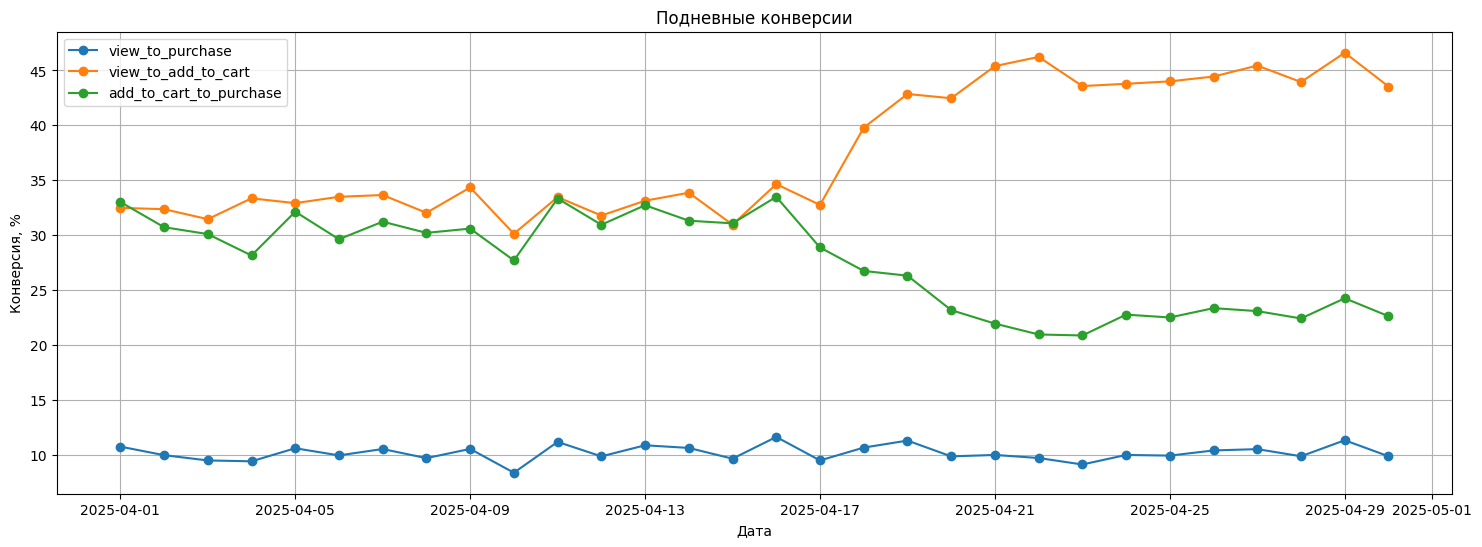

In [26]:
from datetime import timedelta

df['date'] = df['event_ts'].dt.date
events = ['view_item', 'add_to_cart', 'purchase']
df_filt = df[df['event'].isin(events)]

# 1) конверсия из просмотра в покупку

df_conv_1 = df_filt.copy()
df_conv_1['view_item'] = df_conv_1['event'].apply(lambda x: 1 if x == 'view_item'
                                                  else 0)
df_conv_1['purchase'] = df_conv_1['event'].apply(lambda x: 1 if x == 'purchase'
                                                  else 0)

df_conv_1 = df_conv_1.groupby(['date', 'session_id'])[['view_item', 'purchase']].sum().reset_index()

df_conv_1_purch = df_conv_1.query('view_item > 0 and purchase > 0').groupby('date')['session_id'].nunique().reset_index()
df_conv_1_view = df_conv_1.query('view_item > 0').groupby('date')['session_id'].nunique().reset_index()

df_conv_1 = df_conv_1_purch.copy()
df_conv_1['session_id'] = round(df_conv_1_purch['session_id'] / df_conv_1_view['session_id'] * 100, 2)
df_conv_1

# 2) конверсия из просмотра в добавление в корзину

df_conv_2 = df_filt.copy()
df_conv_2['view_item'] = df_conv_2['event'].apply(lambda x: 1 if x == 'view_item'
                                                  else 0)
df_conv_2['add_to_cart'] = df_conv_2['event'].apply(lambda x: 1 if x == 'add_to_cart'
                                                  else 0)

df_conv_2 = df_conv_2.groupby(['date', 'session_id'])[['view_item', 'add_to_cart']].sum().reset_index()

df_conv_2_cart = df_conv_2.query('view_item > 0 and add_to_cart > 0').groupby('date')['session_id'].nunique().reset_index()
df_conv_2_view = df_conv_2.query('view_item > 0').groupby('date')['session_id'].nunique().reset_index()

df_conv_2 = df_conv_2_cart.copy()
df_conv_2['session_id'] = round(df_conv_2_cart['session_id'] / df_conv_2_view['session_id'] * 100, 2)
df_conv_2

# 3) конверсия из добавления в корзину в покупку

df_conv_3 = df_filt.copy()
df_conv_3['add_to_cart'] = df_conv_3['event'].apply(lambda x: 1 if x == 'add_to_cart'
                                                  else 0)
df_conv_3['purchase'] = df_conv_3['event'].apply(lambda x: 1 if x == 'purchase'
                                                  else 0)

df_conv_3 = df_conv_3.groupby(['date', 'session_id'])[['add_to_cart', 'purchase']].sum().reset_index()

df_conv_3_purch = df_conv_3.query('add_to_cart > 0 and purchase > 0').groupby('date')['session_id'].nunique().reset_index()
df_conv_3_cart = df_conv_3.query('add_to_cart > 0').groupby('date')['session_id'].nunique().reset_index()

df_conv_3 = df_conv_3_purch.copy()
df_conv_3['session_id'] = round(df_conv_3_purch['session_id'] / df_conv_3_cart['session_id'] * 100, 2)
df_conv_3

# Объединение в общий датафрейм


df_conv = df_conv_1.copy()
df_conv = pd.merge(df_conv, df_conv_2, how='left', on='date')
df_conv = pd.merge(df_conv, df_conv_3, how='left', on='date')
df_conv.columns = ['date', 'view_to_purchase', 'view_to_add_to_cart', 'add_to_cart_to_purchase']
df_conv.set_index('date', inplace=True)

# Визуализация

df_conv.plot(figsize=(18, 6), marker = 'o')
plt.title('Подневные конверсии')
plt.ylabel('Конверсия, %')
plt.xlabel('Дата')
plt.grid(True)
plt.show()

**Ответ на вопрос о наблюдениях.**

По графикам можно судить о следующем:
1) Тренд конверсии из просмотра в покупку устойчив, но значение самой конверсии мало (в среднем в районе 10%)
2) Конверсия из просмотра в добавление в корзину не падала, а начала расти с 18 апреля
3) Конверсия из добавления в корзину в покупку начала падать с 17 апреля

#### **2. Проверка абсолютных и средних значений — 1 балл**

1) Постройте графики дневной динамики абсолютных значений, из которых рассчитаны конверсии выше.
2) Рассчитайте и визуализируйте среднее число событий (именно событий, не сессий), из которых рассчитаны конверсии, на пользователя.
3) На каком этапе воронки появилась проблема?

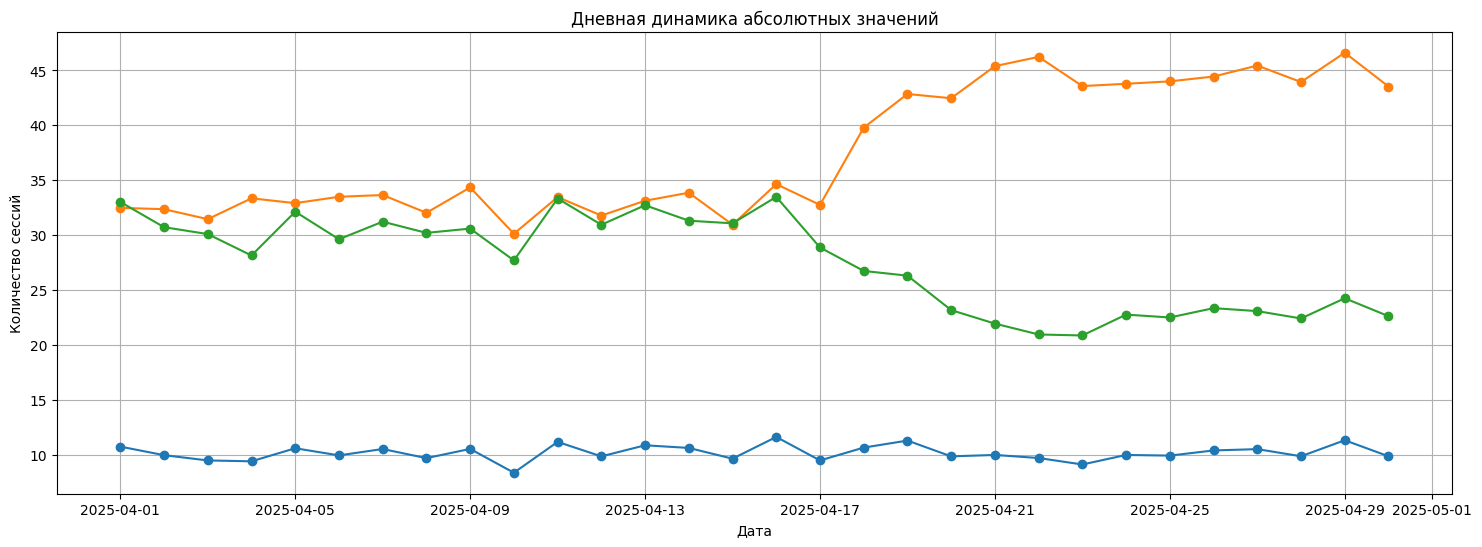

<Figure size 640x480 with 0 Axes>

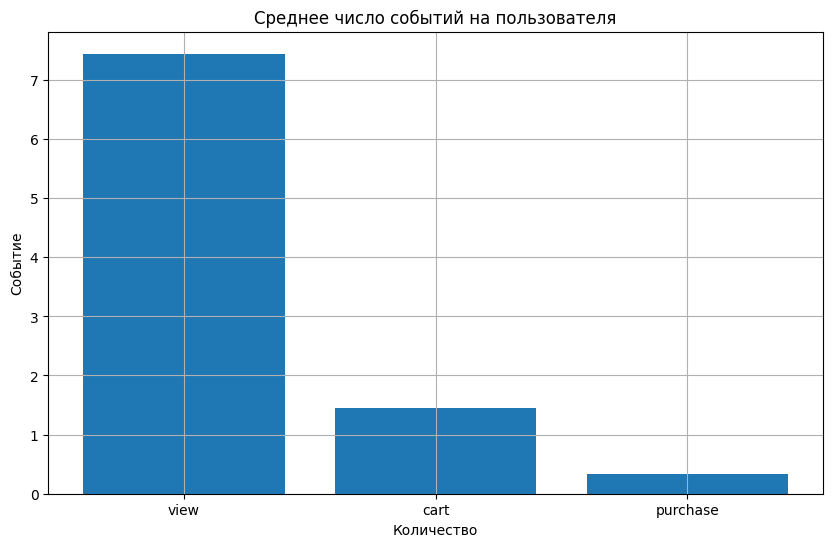

In [27]:
# Графики дневной динамики абсолютных значений

df_2 = df_conv_1_view.copy()
df_2 = pd.merge(df_2, df_conv_1_purch, how='left', on='date')
df_2 = pd.merge(df_2, df_conv_2_cart, how='left', on='date')
df_2.columns = ['date', 'view_item', 'purchase', 'add_to_cart']
df_2.set_index('date', inplace=True)

plt.figure(figsize=(18, 6))
plt.plot(df_conv, marker = 'o')
plt.title('Дневная динамика абсолютных значений')
plt.ylabel('Количество сессий')
plt.xlabel('Дата')
plt.grid(True)
plt.show()

# Среднее число событий на пользователя

df_2_user = df.copy()

df_2_user['view'] = df_2_user['event'].apply(lambda x: 1 if x == 'view_item'
                                                  else 0)
df_2_user['cart'] = df_2_user['event'].apply(lambda x: 1 if x == 'add_to_cart'
                                                  else 0)
df_2_user['purchase'] = df_2_user['event'].apply(lambda x: 1 if x == 'purchase'
                                                  else 0)

users = df_2_user['user_id'].nunique()

df_2_user = df_2_user.groupby('user_id')[['view', 'cart', 'purchase']].sum()
df_2_user = (df_2_user.sum() / users).reset_index()

plt.subplots_adjust(wspace=0.7, hspace=0.7)

plt.figure(figsize=(10, 6))
plt.bar(x = df_2_user['index'], height = df_2_user[0])
plt.title('Среднее число событий на пользователя')
plt.ylabel('Событие')
plt.xlabel('Количество')
plt.grid(True)
plt.show()

***Как видно по графикам, проблемная зона воронки - добавление в корзину***

#### **3. Базовые срезы — 1 балл**
1. Постройте динамику проблемного события в разрезе:
- платформ,
- регионов,
- источников трафика,
- категорий товаров.

2. Есть ли выделяющийся срез?

*В этом пункте в качестве события продолжаем смотреть метрику среднего на пользователя*

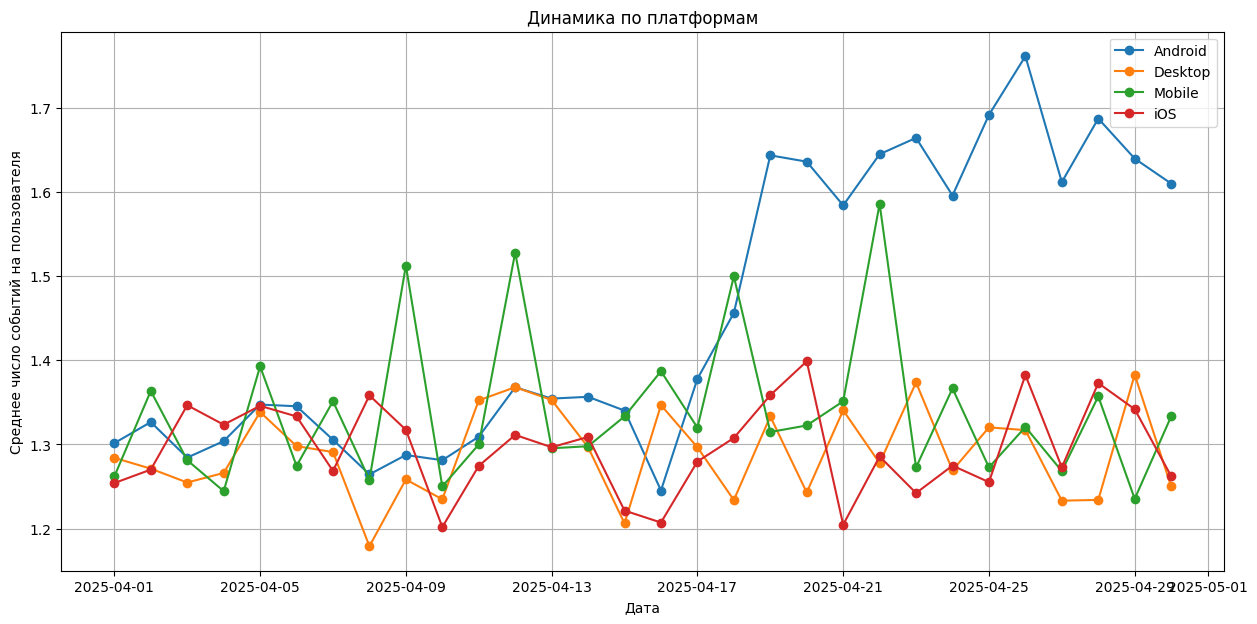

<Figure size 640x480 with 0 Axes>

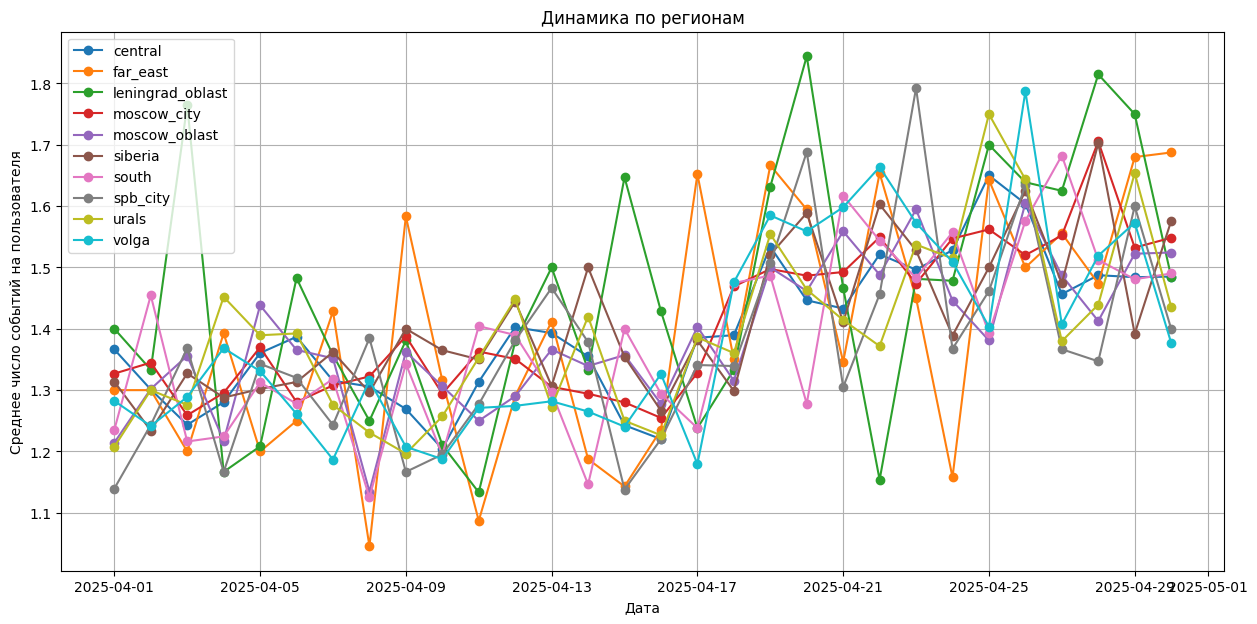

<Figure size 640x480 with 0 Axes>

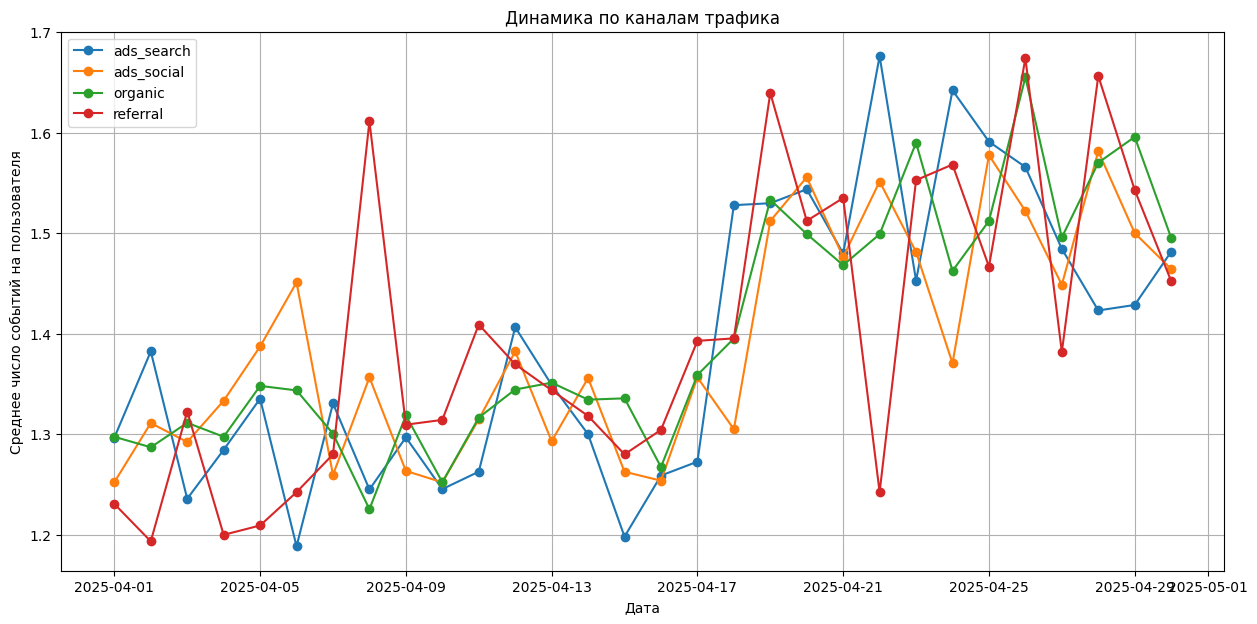

<Figure size 640x480 with 0 Axes>

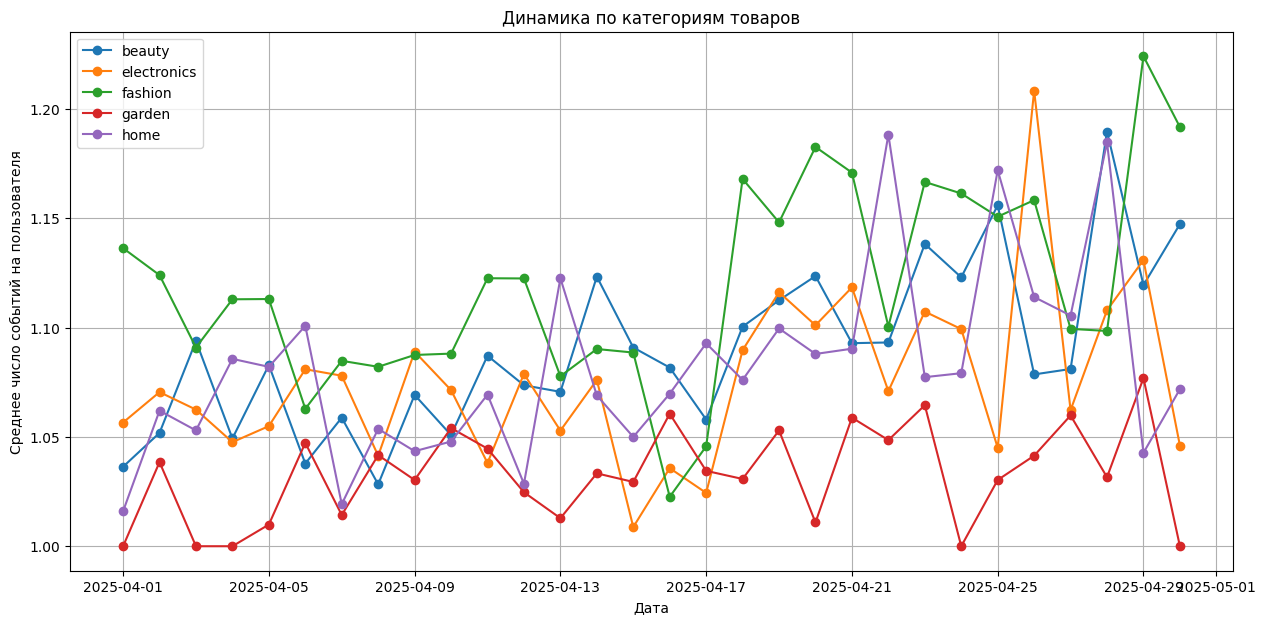

In [58]:
df_3 = df.copy()
df_3 = df_3[df_3['event'] == 'add_to_cart']

# Динамика в разрезе платформ

df_3_pl = df_3.groupby(['platform', 'date']).agg(users = ('user_id', 'nunique'), events = ('event', 'count')).reset_index()
df_3_pl['avg_user'] = df_3_pl['events'] / df_3_pl['users']

plt.figure(figsize=(15, 7))

for x in df_3_pl['platform'].unique():
    df_pl = df_3_pl[df_3_pl['platform'] == x]
    plt.plot(df_pl['date'], df_pl['avg_user'], marker='o', label=x)

plt.xlabel('Дата')
plt.ylabel('Среднее число событий на пользователя')
plt.title('Динамика по платформам')
plt.legend()
plt.grid(True)
plt.show()

# Динамика в разрезе регионов

df_3_reg = df_3.groupby(['date', 'region']).agg(users = ('user_id', 'nunique'), events = ('event', 'count')).reset_index()
df_3_reg['avg_user'] = df_3_reg['events'] / df_3_reg['users']

plt.subplots_adjust(wspace=0.7, hspace=0.7)
plt.figure(figsize=(15, 7))

for x in df_3_reg['region'].unique():
    df_reg = df_3_reg[df_3_reg['region'] == x]
    plt.plot(df_reg['date'], df_reg['avg_user'], marker='o', label=x)

plt.xlabel('Дата')
plt.ylabel('Среднее число событий на пользователя')
plt.title('Динамика по регионам')
plt.legend()
plt.grid(True)
plt.show()

# Динамика в разрезе каналов

df_3_ch = df_3.groupby(['date', 'channel']).agg(users = ('user_id', 'nunique'), events = ('event', 'count')).reset_index()
df_3_ch['avg_user'] = df_3_ch['events'] / df_3_ch['users']

plt.subplots_adjust(wspace=0.7, hspace=0.7)
plt.figure(figsize=(15, 7))

for x in df_3_ch['channel'].unique():
    df_ch = df_3_ch[df_3_ch['channel'] == x]
    plt.plot(df_ch['date'], df_ch['avg_user'], marker='o', label=x)

plt.xlabel('Дата')
plt.ylabel('Среднее число событий на пользователя')
plt.title('Динамика по каналам трафика')
plt.legend()
plt.grid(True)
plt.show()

# Динамика в разрезе категорий товаров

df_3_cat = df_3.groupby(['date', 'category']).agg(users = ('user_id', 'nunique'), events = ('event', 'count')).reset_index()
df_3_cat['avg_user'] = df_3_cat['events'] / df_3_cat['users']

plt.subplots_adjust(wspace=0.7, hspace=0.7)
plt.figure(figsize=(15, 7))

for x in df_3_cat['category'].unique():
    df_cat = df_3_cat[df_3_cat['category'] == x]
    plt.plot(df_cat['date'], df_cat['avg_user'], marker='o', label=x)

plt.xlabel('Дата')
plt.ylabel('Среднее число событий на пользователя')
plt.title('Динамика по категориям товаров')
plt.legend()
plt.grid(True)
plt.show()

***Да, выделяющийся срез - платформа, поскольку там явно выбивается Android***

#### **4. Детальные срезы — 1 балл**
1. Постройте динамику события для iOS и Android с разложением по версиям приложения.
2. Помогло ли это локализовать проблему?

*В этом пункте в качестве события продолжаем смотреть метрику среднего на пользователя*

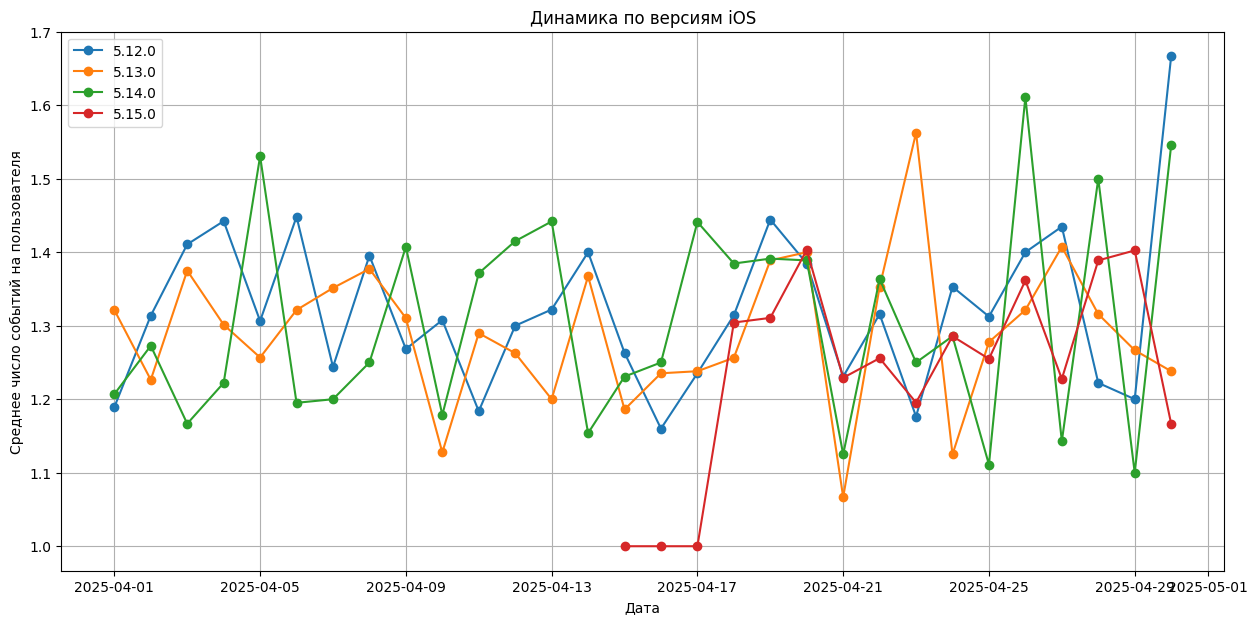

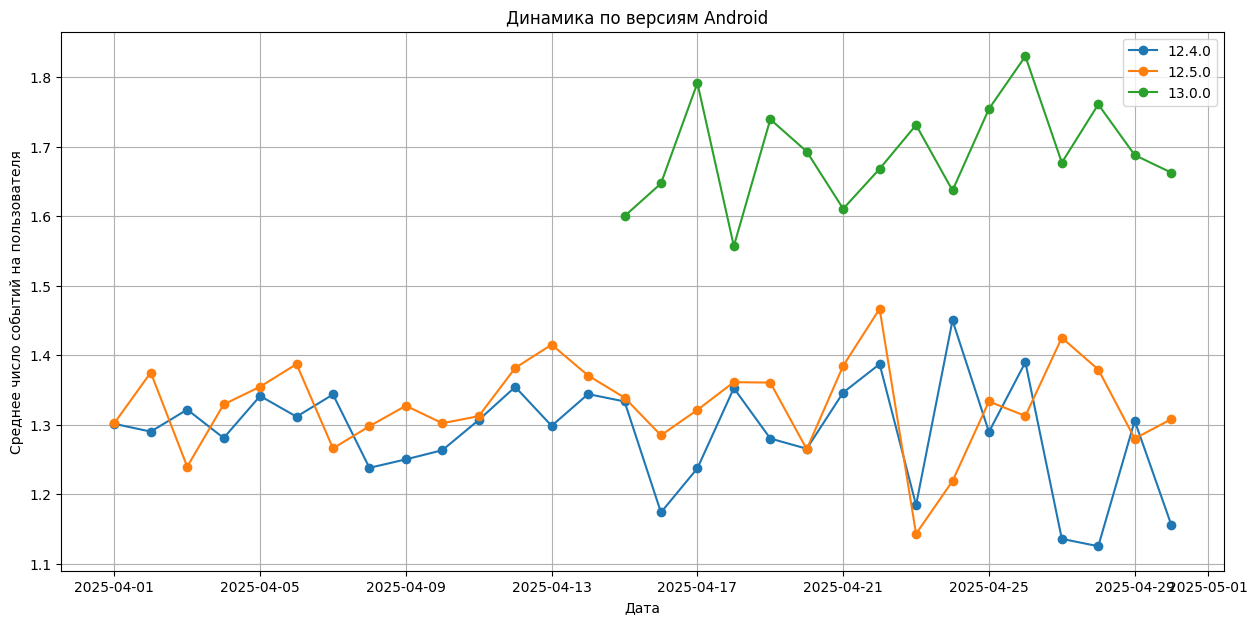

In [57]:
df_4 = df.query('platform == "iOS" or platform == "Android"')
df_4 = df_4.query('event == "add_to_cart"')

df_4 = df_4.groupby(['date', 'platform', 'app_version']).agg(users = ('user_id', 'nunique'),
                                                             events = ('event', 'count')).reset_index()

df_4['avg_purch'] = df_4['events'] / df_4['users']
df_4_ios = df_4.query('platform == "iOS"')
df_4_android = df_4.query('platform == "Android"')

plt.figure(figsize=(15, 7))

for x in df_4_ios['app_version'].unique():
    df_ios_ver = df_4_ios[df_4_ios['app_version'] == x]
    plt.plot(df_ios_ver['date'], df_ios_ver['avg_purch'], marker='o', label=x)

plt.xlabel('Дата')
plt.ylabel('Среднее число событий на пользователя')
plt.title('Динамика по версиям iOS')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 7))

for x in df_4_android['app_version'].unique():
    df_ios_ver = df_4_android[df_4_android['app_version'] == x]
    plt.plot(df_ios_ver['date'], df_ios_ver['avg_purch'], marker='o', label=x)

plt.xlabel('Дата')
plt.ylabel('Среднее число событий на пользователя')
plt.title('Динамика по версиям Android  ')
plt.legend()
plt.grid(True)
plt.show()

***В целом локализовать проблему удалось, явно видно, что на платформе iOS при выходе новой версии график примерно такой же, а у Android новая версия показывает значительно иные результаты.***

#### **5. Поиск причин — 1 балл**
1. Для проблемной платформы постройте динамику ВСЕХ событий в разрезе версий приложения.
2. Сформулируйте гипотезу, что именно могло пойти не так в новом релизе? Может быть, пользователи стали заменять один функционал другим?

*В этом пункте в качестве событий продолжаем смотреть метрику среднего на пользователя*

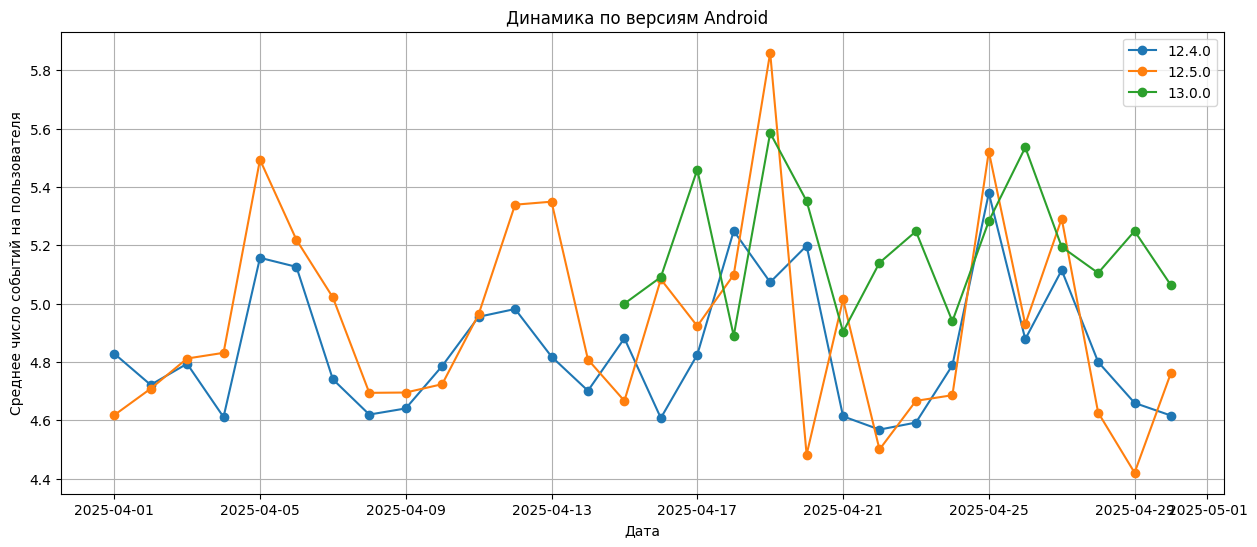

In [61]:
df_5 = df.copy()
df_5 = df_5.query('platform == "Android"')

df_5 = df_5.groupby(['date', 'app_version']).agg(users = ('user_id', 'nunique'),
                                                 events = ('event', 'count')).reset_index()

df_5['avg_purch'] = df_5['events'] / df_5['users']

plt.figure(figsize=(15, 6))

for x in df_5['app_version'].unique():
    df_5_android = df_5[df_5['app_version'] == x]
    plt.plot(df_5_android['date'], df_5_android['avg_purch'], marker='o', label=x)

plt.xlabel('Дата')
plt.ylabel('Среднее число событий на пользователя')
plt.title('Динамика по версиям Android  ')
plt.legend()
plt.grid(True)
plt.show()

После релиза новой версии пользователи стали чаще добавлять товары в корзину, при том общее число событий изменилось незначительно, что может свидетельствовать о том, что совершать покупку пользователям стало труднее. Вероятно появились проблемы с проведением оплаты. В связи с чем нам необходимо добавить новые возможности для совершения покупки через наш маркетплейс для пользователей Android на версии 13.0.0

#### **6. Новости для команды — 1 балл**

На основе проведённого расследования подготовьте сообщение для команды о том, что именно пошло не так.

За последние 14 дней наблюдается сильный спад добавления товаров в корзину. Я провела анализ, который позволил выявить следующее:
1) Данная проблема наиболее сильно связана с платформой, с которой коиент пользуется нашим маркетплейсом
2) Если рассматривать наиболее популярные платформы - iOS и Android - можно заметить, что 15 апреля был релиз новой версии Android (13.0.0), что наиболее сильно выделяется в разрезе проблемного события (добавление товара в корзину)
3) При просмотре всех событий, совершенных на Android, было выявлено, что среднее количество всех совершенных действий на 1 пользователя, изменилось незначительно
4) Поскольку добавление товара в корзину у пользователей Android с выходом новой врсии повысилось, а общее число действий изменилось незначительно, можно предположить, что в новом релизе стало неудобно совершать оплату, в связи с чем нам неободимо продумать новые возможности покупки через наш маркетплейс для пользователей Android новой версии.